# データ取得
JEXPデータを`Python`経由で取得したい

https://www.jepx.jp/electricpower/market-data/spot/

ホームページをスクレイピングする。まずは開発者ツールでどのようにダウンロードできているのかを確認する。

```HTML
<form method="post" action="/_download.php?...">
```

`POST`でリクエストを送っていることやリクエスト先がわかる。

parameterは

```HTML
<input name="dir" value="spot_summary">
<option value="spot_summary_2026.csv">
```

In [1]:
import requests

In [2]:
from pathlib import Path

# 保存先ディレクトリ
save_dir = Path("../data/raw/electricity")

# 保存ファイルパス
save_path = save_dir / "spot_summary_2026.csv"

In [3]:
# Cookie維持
session = requests.Session()
session.get(
    "https://www.jepx.jp/electricpower/market-data/spot/ave_day.html"
)

# パラメータ設定
url = "https://www.jepx.jp/_download.php?timestamp=1778938883372"
headers = {
    "Referer": "https://www.jepx.jp/electricpower/market-data/spot/ave_day.html",# どのページから来たか
    "User-Agent": "Mozilla/5.0"#
}
data = {
    "dir": "spot_summary",
    "file": "spot_summary_2026.csv"
}

# リクエスト
response = session.post(url, data=data, headers=headers)

# ステータス確認
if response.status_code != 200:
    print(f"HTTPエラー: {response.status_code}")

# Content-Type確認
elif "application/octet-stream" not in response.headers.get("Content-Type", ""):
    print("CSVファイルではありません")

# データサイズ確認
elif len(response.content) < 1000:
    print("レスポンスが小さすぎます")

# 正常系
else:
    print("CSV取得成功")

    print(response.status_code)
    print(response.headers.get("Content-Type"))
    print(response.text[:200])
    print(len(response.content))

    with open(save_path, "wb") as f:
        f.write(response.content)

    print("ファイル保存完了")

CSV取得成功
200
application/octet-stream; name=spot_summary_2026.csv
受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプラ
292965
ファイル保存完了


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
TOKYO_COL = "エリアプライス東京(円/kWh)"

# データ保存ディレクトリ
DATA_DIR = Path("../data/raw/electricity")

def load_jepx(year):
    file_path = DATA_DIR / f"spot_summary_{year}.csv"

    df = pd.read_csv(file_path, encoding="cp932")

    df["datetime"] = (
        pd.to_datetime(df["受渡日"])
        + pd.to_timedelta((df["時刻コード"] - 1) * 30, unit="m")
    )

    df[TOKYO_COL] = pd.to_numeric(
        df[TOKYO_COL],
        errors="coerce"
    )

    return df

df2025 = load_jepx(2025)
df2026 = load_jepx(2026)

df2026.tail()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),datetime
2251,2026/05/17,44,25906050,21656800,15342900,15.79,16.44,16.44,16.44,16.44,16.44,16.44,16.44,16.44,11.77,9715300,2125400,1165150,692850,2026-05-17 21:30:00
2252,2026/05/17,45,25879350,20694200,15084250,15.66,16.36,16.36,16.36,16.36,16.36,16.36,16.36,16.36,11.77,9798050,2179150,1163700,698900,2026-05-17 22:00:00
2253,2026/05/17,46,25905900,21691450,16558900,17.04,19.25,19.25,50.00,19.31,16.25,16.25,16.25,16.25,11.77,9701350,2239200,1161250,696450,2026-05-17 22:30:00
2254,2026/05/17,47,25284250,21485150,16448550,16.95,18.50,18.50,35.83,25.31,16.25,16.25,16.25,16.25,9.78,9353400,2281600,1159750,694950,2026-05-17 23:00:00
2255,2026/05/17,48,24567400,20358550,16167500,16.36,20.68,20.68,20.68,20.68,13.58,13.58,13.58,13.58,9.78,8707500,2339850,629300,512000,2026-05-17 23:30:00


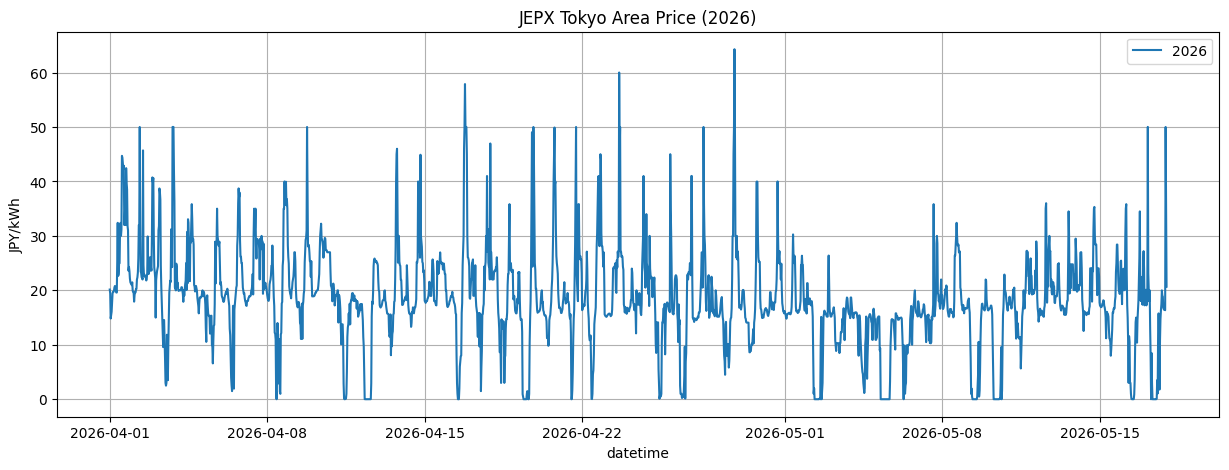

In [7]:
plt.figure(figsize=(15, 5))

plt.plot(
    df2026["datetime"],
    df2026[TOKYO_COL],
    label="2026"
)

plt.title("JEPX Tokyo Area Price (2026)")
plt.xlabel("datetime")
plt.ylabel("JPY/kWh")

plt.legend()
plt.grid(True)

plt.show()

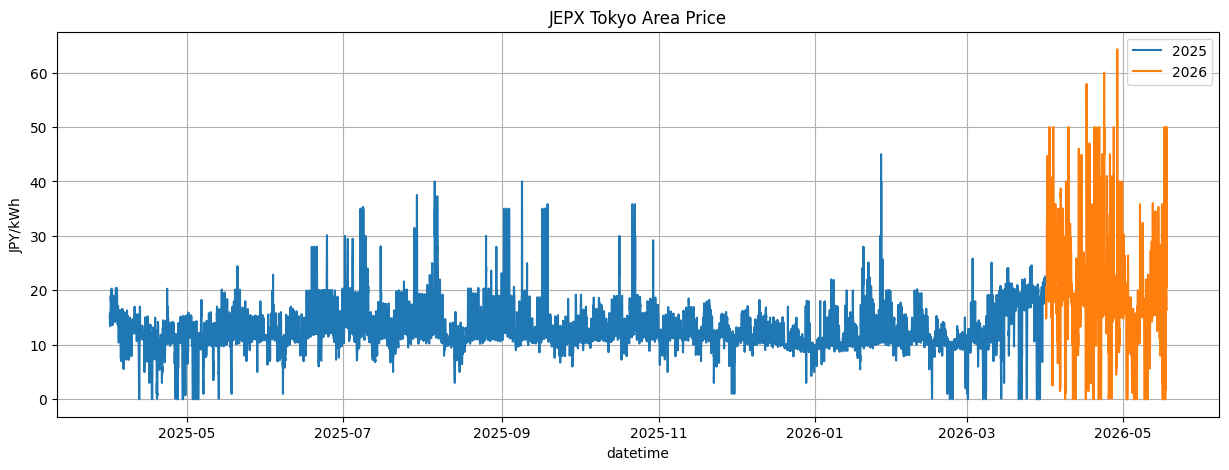

In [6]:
plt.figure(figsize=(15, 5))
plt.plot(df2025["datetime"], df2025[TOKYO_COL], label="2025")
plt.plot(df2026["datetime"], df2026[TOKYO_COL], label="2026")

plt.title("JEPX Tokyo Area Price")
plt.xlabel("datetime")
plt.ylabel("JPY/kWh")
plt.legend()
plt.grid(True)
plt.show()